In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from mpl_toolkits.mplot3d import Axes3D

In [2]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
print("Dataset fits in memory:", df.memory_usage(deep=True).sum(), "bytes")

Dataset fits in memory: 20068 bytes


In [4]:
print("Null values:\n", df.isnull().sum())
print("Data types:\n", df.dtypes)
print("Class distribution:\n", df['target'].value_counts())

Null values:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64
Data types:
 alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
prol

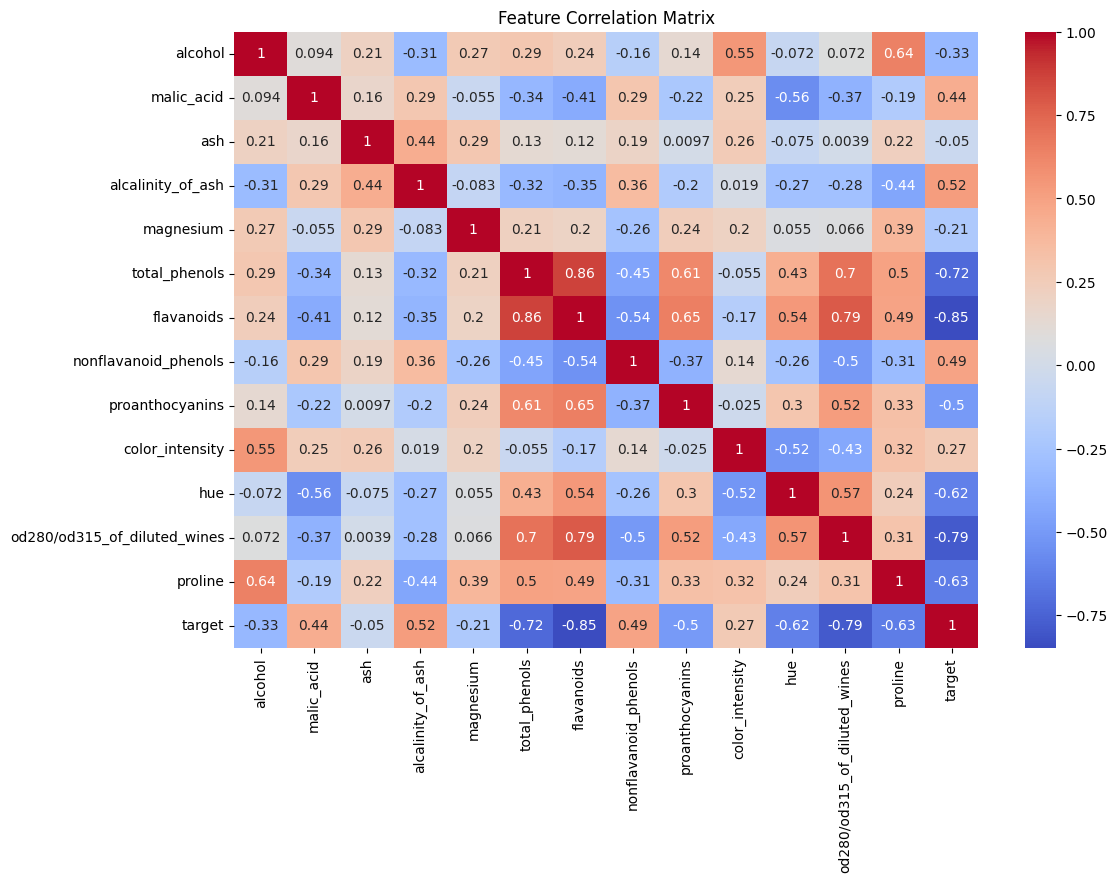

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

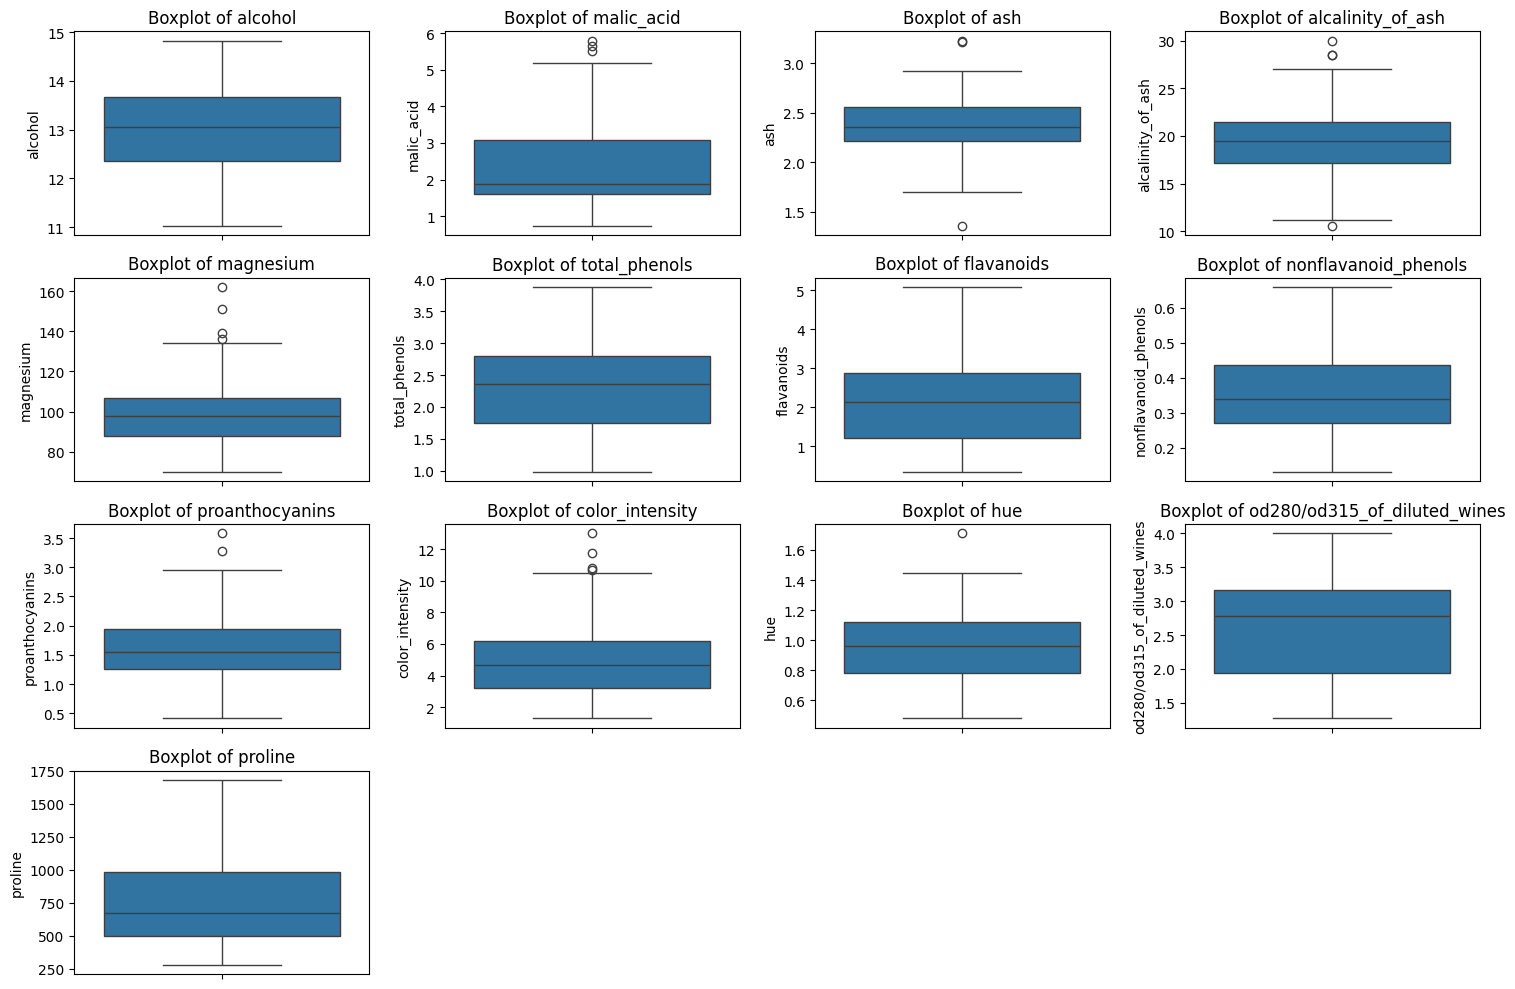

In [6]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns[:-1]):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

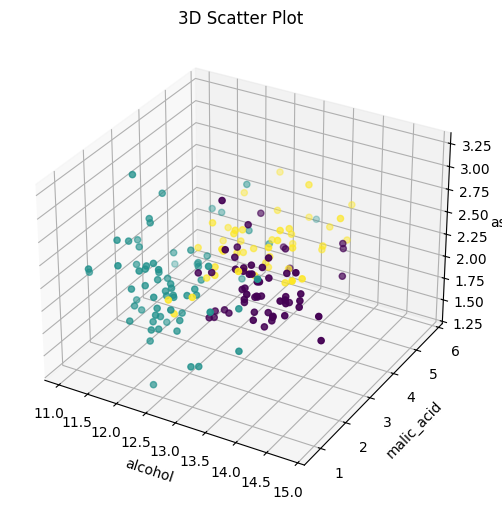

In [7]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df.iloc[:, 0], df.iloc[:, 1], df.iloc[:, 2], c=df['target'], cmap='viridis')
ax.set_xlabel(wine.feature_names[0])
ax.set_ylabel(wine.feature_names[1])
ax.set_zlabel(wine.feature_names[2])
plt.title('3D Scatter Plot')
plt.show()

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns='target'))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

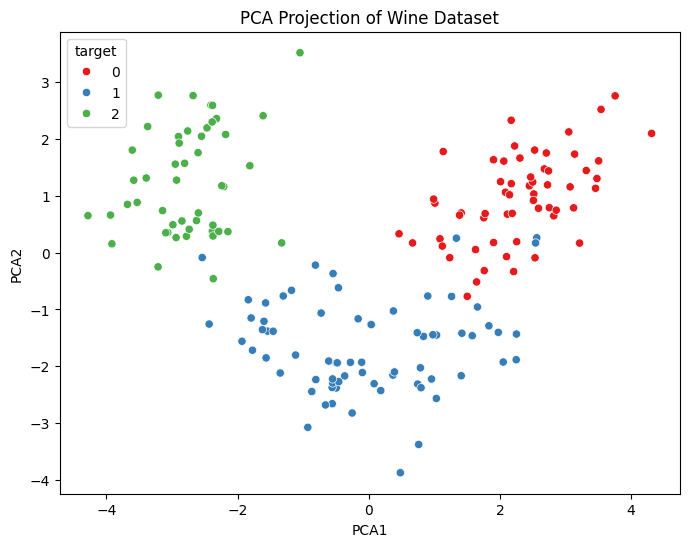

In [9]:
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='target', data=df, palette='Set1')
plt.title('PCA Projection of Wine Dataset')
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

In [11]:
pipeline = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])
param_grid = {
    'clf__n_estimators': [10, 50, 100],
    'clf__max_depth': [None, 5, 10]
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__max_depth': [None, 5, ...], 'clf__n_estimators': [10, 50, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,50


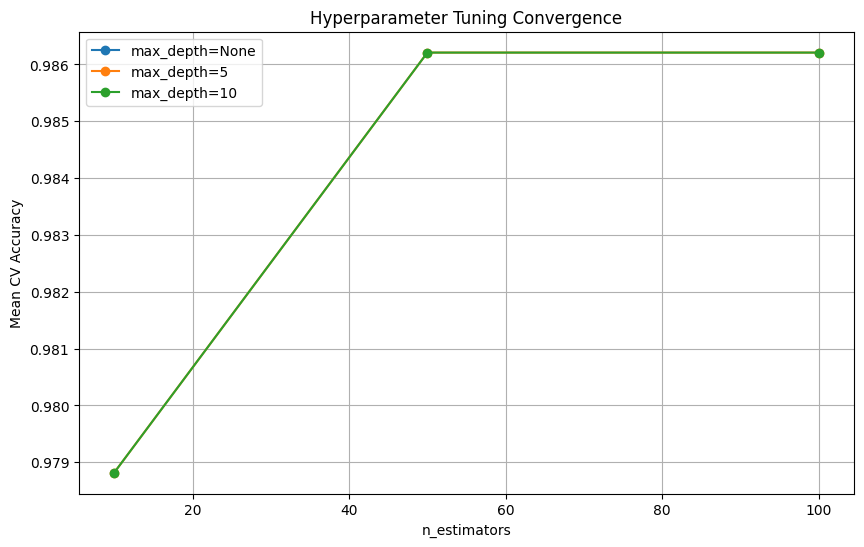

In [12]:
results_df = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
for depth in [None, 5, 10]:
    subset = results_df[results_df['param_clf__max_depth'] == depth]
    plt.plot(subset['param_clf__n_estimators'], subset['mean_test_score'], marker='o', label=f'max_depth={depth}')
plt.xlabel('n_estimators')
plt.ylabel('Mean CV Accuracy')
plt.title('Hyperparameter Tuning Convergence')
plt.legend()
plt.grid(True)
plt.show()

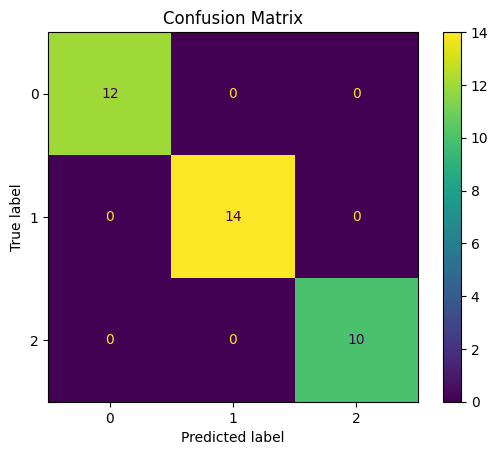

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [13]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred))